/var/folders/1v/pf54418j6fj5541rk7ynqhgw0000gn/T/ipykernel_49495/2506742003.py:8: RuntimeWarning: invalid value encountered in subtract
  return chi_k + digamma(alpha_k + alpha_2) - digamma(alpha_k)


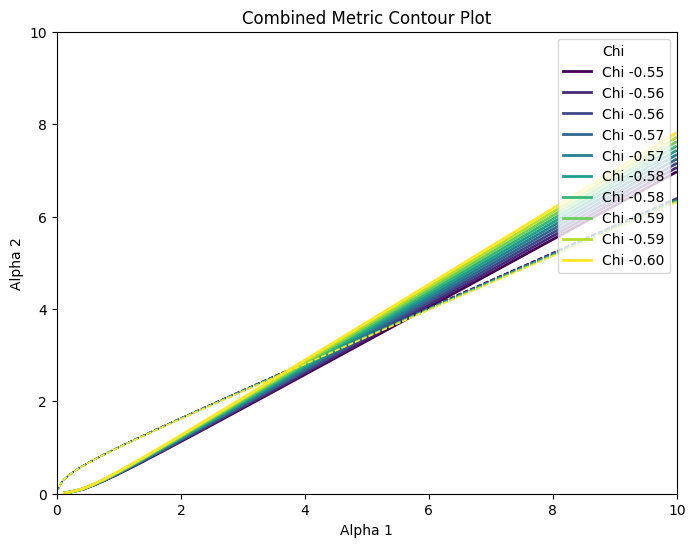

In [ ]:
from scipy.special import digamma
import numpy as np
import matplotlib.pyplot as plt

alpha_1, alpha_2 = np.meshgrid(np.linspace(0, 10, 100), np.linspace(0, 10, 100))

def compute_metric(chi_k, alpha_k, alpha_2):
    return chi_k + digamma(alpha_k + alpha_2) - digamma(alpha_k)

chi_1 = np.linspace(-0.55, -0.6, 10)
chi_2 = np.linspace(-0.99, -1, 10)

plt.figure(figsize=(8, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(chi_1)))
handles = []

for chi_k, color in zip(chi_1, colors):
    z_1 = compute_metric(chi_k, alpha_1, alpha_2)
    plt.contour(alpha_1, alpha_2, z_1, levels=[0], colors=[color], linewidths=2)
    handles.append(plt.Line2D([0], [0], color=color, lw=2, label=f'Chi {chi_k:.1f}'))

plt.xlabel('Alpha 1')
plt.ylabel('Alpha 2')
plt.title('Metric Contour Plot')
plt.legend(handles=handles, title='Chi')
plt.show()

plt.figure(figsize=(8, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(chi_1)))
handles = []

for chi_k, color in zip(chi_2, colors):
    z_1 = compute_metric(chi_k, alpha_2, alpha_1)
    plt.contour(alpha_1, alpha_2, z_1, levels=[0], colors=[color], linewidths=2)
    handles.append(plt.Line2D([0], [0], color=color, lw=2, label=f'Chi {chi_k:.1f}'))

plt.xlabel('Alpha 1')
plt.ylabel('Alpha 2')
plt.title('Metric Contour Plot')
plt.legend(handles=handles, title='Chi')
plt.show()


/var/folders/1v/pf54418j6fj5541rk7ynqhgw0000gn/T/ipykernel_49495/2506742003.py:8: RuntimeWarning: invalid value encountered in subtract
  return chi_k + digamma(alpha_k + alpha_2) - digamma(alpha_k)


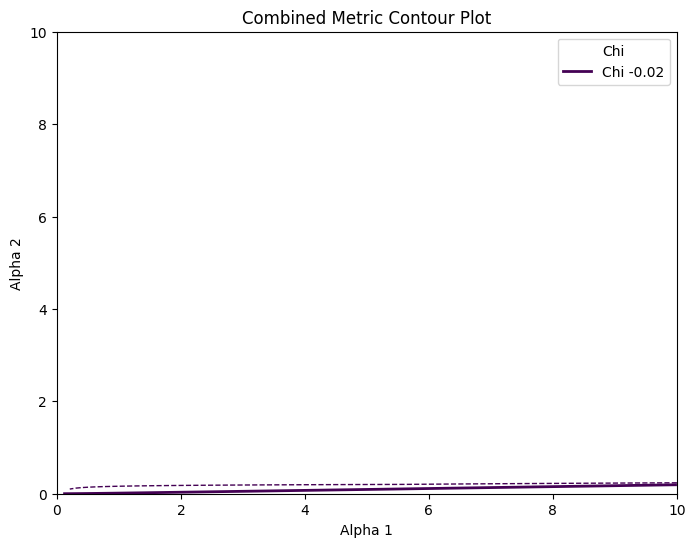

In [80]:
chi_1 = np.log([0.98])
chi_2 = np.log([0.001])

# chi_1 = np.linspace(-0.55, -0.6, 10)
# chi_2 = np.linspace(-0.99, -1, 10)

plt.figure(figsize=(8, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(chi_1)))
handles = []

for (chi_k1, chi_k2), color in zip(zip(chi_1, chi_2), colors):
    z_1 = compute_metric(chi_k1, alpha_1, alpha_2)
    z_2 = compute_metric(chi_k2, alpha_2, alpha_1)
    plt.contour(alpha_1, alpha_2, z_1, levels=[0], colors=[color], linewidths=2)
    plt.contour(alpha_1, alpha_2, z_2, levels=[0], colors=[color], linewidths=1, linestyles='dashed')
    handles.append(plt.Line2D([0], [0], color=color, lw=2, label=f'Chi {chi_k1:.2f}'))

plt.xlabel('Alpha 1')
plt.ylabel('Alpha 2')
plt.title('Combined Metric Contour Plot')
plt.legend(handles=handles, title='Chi')
plt.show()

In [ ]:
import numpy as np
from scipy.special import digamma, polygamma

def inv_digamma(y, n_newton=5):
    # Minka's initializer: accurate to ~1e-2, Newton converges quadratically
    x = np.where(y >= -2.22, np.exp(y) + 0.5, -1.0 / (y - digamma(1)))
    for _ in range(n_newton):
        x = x - (digamma(x) - y) / polygamma(1, x)
    return x

def solve_alpha_fp(X, tol=1e-3, max_iter=600):
    X = np.asarray(X, dtype=np.float64)
    X = np.log(X)
    assert np.all(X < 0), "need X[k] < 0 for a solution to exist"

    # init from the marginal: ignore ψ(Σα) term on first pass
    alpha = inv_digamma(X + digamma(2))

    for _ in range(max_iter):
        s = digamma(alpha.sum())
        new_alpha = inv_digamma(X + s)
        if np.max(np.abs(new_alpha - alpha)) < tol:
            alpha = new_alpha
            break
        alpha = new_alpha

    print(f"converged in {_} iterations")
    return alpha, alpha / alpha.sum()

alpha, p = solve_alpha_fp(np.array([0.6, 0.3]))
alpha, p

ImportError: cannot import name 'idigamma' from 'scipy.special' (/opt/anaconda3/envs/pyldl/lib/python3.11/site-packages/scipy/special/__init__.py)

In [170]:
def BDL(b, a=None, W=1/2):
    if a is None:
        a = np.ones_like(b)/len(b)

    u = 1 - np.sum(b)
    alpha = W*(b/u + a)
    return alpha, alpha/alpha.sum()

In [171]:
b = np.array([0.6, 0.3])
alpha, p = BDL(b, b)
print(f"BDL model alpha: {alpha}, p: {p}")
alpha, p = solve_alpha_fp(b)
print(f"FP model alpha: {alpha}, p: {p}")

BDL model alpha: [3.3  1.65], p: [0.66666667 0.33333333]
converged in 54 iterations
FP model alpha: [3.27029055 1.86400354], p: [0.63695038 0.36304962]


In [173]:
b = np.array([0.66, 0.33])
alpha, p = BDL(b, b)
print(f"BDL model alpha: {alpha}, p: {p}")
alpha, p = solve_alpha_fp(b)
print(f"FP model alpha: {alpha}, p: {p}")

BDL model alpha: [33.33  16.665], p: [0.66666667 0.33333333]
converged in 579 iterations
FP model alpha: [33.20359641 16.84988818], p: [0.66336233 0.33663767]


In [152]:
b = np.array([0.85, 0.05])
alpha, p = BDL(b)
print(f"BDL model alpha: {alpha}, p: {p}")
alpha, p = solve_alpha_fp(b)
print(f"FP model alpha: {alpha}, p: {p}")

BDL model alpha: [4.5 0.5], p: [0.9 0.1]
converged in 60 iterations
FP model alpha: [3.67081169 0.56480038], p: [0.86665436 0.13334564]


In [153]:
b = np.array([0.9, 0.075])
alpha, p = BDL(b)
print(f"BDL model alpha: {alpha}, p: {p}")
alpha, p = solve_alpha_fp(b)
print(f"FP model alpha: {alpha}, p: {p}")

BDL model alpha: [18.25  1.75], p: [0.9125 0.0875]
converged in 253 iterations
FP model alpha: [17.43647513  1.88341134], p: [0.90251437 0.09748563]
